In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, HTML

from astroquery.gaia import Gaia
from scipy.interpolate import RegularGridInterpolator
from isochrones.mist import MIST_Isochrone
import emcee

# synphot 
from synphot.reddening import ReddeningLaw
import astropy.units as u

mist = MIST_Isochrone() 

In [3]:
# helper functions
def get_distance_pc(ra, dec, radius=2/3600):
    """Query Gaia DR3 for parallax near RA/Dec. Returns distance in parsecs."""
    query = f"""
    SELECT TOP 1 parallax
    FROM gaiadr3.gaia_source
    WHERE CONTAINS(
        POINT('ICRS', ra, dec),
        CIRCLE('ICRS', {ra}, {dec}, {radius})
    ) = 1
    """
    job = Gaia.launch_job(query)
    result = job.get_results()
    if len(result) == 0: return np.nan
    parallax = result['parallax'][0]
    if parallax <= 0: return np.nan
    return 1000.0 / parallax

def apparent_to_absolute(m, d_pc):
    """Convert apparent magnitude to absolute magnitude."""
    return m - 5*np.log10(d_pc) + 5

In [4]:
# load and merge data
df1 = pd.read_csv("/Users/elenadickens/Desktop/ASTR_502/ASTR502_Master_Target_List.csv")
df2 = pd.read_csv("/Users/elenadickens/Desktop/ASTR_502/ASTR502_Master_Photometry_List.csv")

df1 = df1.drop_duplicates(subset="hostname")
df2 = df2.drop_duplicates(subset="hostname")

merged = pd.merge(df1, df2, on="hostname", how="inner")
merged["ra"] = merged["ra_x"]
merged["dec"] = merged["dec_x"]
merged = merged.drop(columns=["ra_x","ra_y","dec_x","dec_y","pl_name_y"])

merged = merged[[
    "hostname","st_teff","st_age","st_met",
    "ra","dec",
    "gaia_Gmag","gaia_BPmag","gaia_RPmag",
    "Jmag","Hmag","Kmag",
    "e_Jmag","e_Hmag","e_Kmag"
]]

merged = merged.dropna(subset=[
    "st_teff","st_age","st_met",
    "ra","dec",
    "gaia_Gmag","gaia_BPmag","gaia_RPmag",
    "Jmag","Hmag","Kmag"
])

merged["st_met"] = merged["st_met"].fillna(0.0)
merged["e_Jmag"] = merged["e_Jmag"].fillna(0.03)
merged["e_Hmag"] = merged["e_Hmag"].fillna(0.03)
merged["e_Kmag"] = merged["e_Kmag"].fillna(0.03)

# query gaia distances
merged_sample = merged.head(100)  # small sample for testing
merged_sample["distance_pc"] = merged_sample.apply(
    lambda row: get_distance_pc(row["ra"], row["dec"]), axis=1
)
merged_sample = merged_sample.dropna(subset=["distance_pc"])
merged_sample = merged_sample[merged_sample["distance_pc"] <= 100]

print("Stars within 100 pc:", len(merged_sample))
display(HTML(merged_sample.head(20).to_html()))

Stars within 100 pc: 20


/var/folders/q7/mvl13nnj2v58d6nv9yfjq7680000gn/T/ipykernel_38571/1111096504.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_sample["distance_pc"] = merged_sample.apply(


,hostname,st_teff,st_age,st_met,ra,dec,gaia_Gmag,gaia_BPmag,gaia_RPmag,Jmag,Hmag,Kmag,e_Jmag,e_Hmag,e_Kmag,distance_pc
0,HIP 65 A,4590.0,4.10,0.180,0.185606,-54.830823,10.588468,11.212916,9.835994,8.922,8.400,8.290,0.019,0.031,0.025,61.865322
5,TOI-198,3650.0,5.30,-0.700,2.271509,-27.121745,10.915721,11.910542,9.930160,8.655,8.143,7.856,0.024,0.026,0.021,23.776037
7,Gliese 12,3296.0,7.00,-0.320,3.957914,13.557617,11.399355,12.830511,10.227193,8.619,8.068,7.807,0.020,0.026,0.020,12.166368
10,HD 1397,5521.0,4.51,0.290,4.447163,-66.358929,7.605658,7.984488,7.055598,6.442,6.090,5.988,0.020,0.049,0.018,80.042045
13,TOI-260,4026.0,15.90,-0.470,4.773018,-9.966150,9.316666,10.124876,8.434608,7.376,6.710,6.549,0.020,0.031,0.021,20.211922
23,TOI-178,4316.0,6.00,-0.230,7.302011,-30.454116,11.157550,11.839834,10.360156,9.372,8.761,8.656,0.021,0.023,0.021,62.89296
27,HD 3167,5261.0,7.80,0.040,8.740149,4.380721,8.772422,9.178295,8.196435,7.548,7.203,7.066,0.032,0.038,0.020,47.312007
33,TOI-1470,3709.0,1.30,0.000,10.089143,61.213387,12.542486,13.669263,11.486450,10.154,9.514,9.283,0.024,0.032,0.020,51.739129
34,TOI-244,3433.0,7.00,-0.390,10.569754,-36.717974,11.548954,12.933047,10.387751,8.827,8.251,7.970,0.023,0.033,0.029,22.075149
35,LHS 1140,3096.0,5.00,-0.150,11.248632,-15.274109,12.653936,14.414495,11.383511,9.612,9.092,8.821,0.023,0.026,0.024,14.963621


In [19]:
# build MIST interpolation grid
age_grid  = np.linspace(6.0,10.2,60)
feh_grid  = np.linspace(-2.5,0.5,31)
mass_grid = np.linspace(0.1,10.0,200)

bands_interp = ['J_mag','H_mag','K_mag','G_mag','BP_mag','RP_mag','Teff']
shape = (len(age_grid), len(feh_grid), len(mass_grid))
cubes = {band: np.full(shape, np.nan) for band in bands_interp}

for i, age in enumerate(age_grid):
    for j, feh in enumerate(feh_grid):
        iso = mist.isochrone(age, feh)
        if iso.empty: continue
        iso = iso.sort_values("initial_mass")
        for band in bands_interp:
            cubes[band][i,j,:] = np.interp(
                mass_grid,
                iso["initial_mass"],
                iso[band],
                left=np.nan, right=np.nan
            )

interpolators = {}
for band in bands_interp:
    interpolators[band] = RegularGridInterpolator(
        (age_grid, feh_grid, mass_grid),
        cubes[band],
        bounds_error=False,
        fill_value=np.nan
    )

import numpy as np
import pandas as pd
from dust_extinction.parameter_averages import CCM89
import astropy.units as u
import emcee

nwalkers = 32
steps = 2000
fit_bands = ["G", "BP", "RP", "J", "H", "K"]
band_map = {b: b+"_mag" for b in fit_bands}

# define central wavelengths for the bands in Angstroms
band_wavelengths = {
    "G": 6231,
    "BP": 5323,
    "RP": 7725,
    "J": 12350,
    "H": 16620,
    "K": 21590
}

# example reddening law: Cardelli+1989 via Synphot
ext_model = CCM89(Rv=3.1) 

def apparent_to_absolute(m_app, distance_pc):
    return m_app - 5*np.log10(distance_pc/10)

# convert row to star dict
def row_to_star(row):
    d = row["distance_pc"]
    return {
        "hostname": row["hostname"],
        "ra": row.get("ra", 0.0),
        "dec": row.get("dec", 0.0),
        "distance_pc": d,
        "photometry": {
            "G": apparent_to_absolute(row["gaia_Gmag"], d),
            "BP": apparent_to_absolute(row["gaia_BPmag"], d),
            "RP": apparent_to_absolute(row["gaia_RPmag"], d),
            "J": apparent_to_absolute(row["Jmag"], d),
            "H": apparent_to_absolute(row["Hmag"], d),
            "K": apparent_to_absolute(row["Kmag"], d),
        },
        "phot_err": {
            "G": 0.01, "BP": 0.01, "RP": 0.01,
            "J": row.get("e_Jmag", 0.02),
            "H": row.get("e_Hmag", 0.02),
            "K": row.get("e_Kmag", 0.02)
        },
        "Teff": row.get("st_teff", 5000.0),
        "feh": row.get("st_met", 0.0),
        "age_true": row.get("st_age", np.nan)
    }

# Chi^2 Model
def chi2_model(params, star):
    logage, mass, Av = params
    feh = np.clip(star["feh"], feh_grid.min(), feh_grid.max())

    y = np.array([star["photometry"][b] for b in fit_bands])
    yerr = np.array([star["phot_err"].get(b, 0.02) for b in fit_bands])
    model_mags = np.array([interpolators[band_map[b]]([[logage, feh, mass]])[0] for b in fit_bands])
    if np.any(np.isnan(model_mags)): 
        return 1e10

    # convert Av → E(B-V)
    Rv = 3.1
    Ebv = Av / Rv

    # apply Synphot extinction
    A_lambda = []
    for b in fit_bands:
        wave = band_wavelengths[b] * u.AA
        A_lambda.append(ext_model(wave) * Av)

    model_mags_ext = model_mags + np.array(A_lambda)

    chi2_phot = np.sum(((y - model_mags_ext)/yerr)**2)

    Teff_model = interpolators["Teff"]([[logage, feh, mass]])[0]
    if np.isnan(Teff_model): 
        return 1e10
    chi2_teff = ((star["Teff"] - Teff_model)/100)**2

    # penalize extremely low-mass solutions
    if mass < 0.5:
        chi2_lowmass = ((0.5 - mass)/0.2)**2
    else:
        chi2_lowmass = 0

    return chi2_phot + chi2_teff + chi2_lowmass

# log-probability for MCMC 
def log_probability(params, star):
    logage, mass, Av = params

    # hard bounds 
    if not (6.0 < logage < 10.2): return -np.inf
    if not (0.1 < mass < 2.5): return -np.inf  
    if not (0.0 <= Av <= 0.3): return -np.inf

    # likelihood
    loglike = -0.5 * chi2_model(params, star)

    # priors

    # 1. mass prior (IMF-like, favors ~0.7–1.2 Msun)
    log_prior_mass = -0.5 * ((mass - 1.0)/0.3)**2

    # 2. extinction prior 
    # nearby stars → Av should be small
    d = star["distance_pc"]

    # scale extinction expectation with distance
    Av_expected = 0.001 * d   # ~0.1 at 100 pc
    Av_sigma = 0.05 + 0.001*d

    log_prior_Av = -0.5 * ((Av - Av_expected)/Av_sigma)**2

    # 3. weak age prior (optional but stabilizes)
    log_prior_age = -0.5 * ((logage - 9.5)/1.5)**2

    return loglike + log_prior_mass + log_prior_Av + log_prior_age

# fit a single star
def fit_star_emcee(star):
    ndim = 3
    # initialize walkers
    logage_init = np.random.normal(9.5, 0.5, nwalkers)
    mass_init = np.random.normal(1.0, 0.2, nwalkers)
    Av_init = np.abs(np.random.normal(0.05, 0.05, nwalkers))
    pos = np.vstack([logage_init, mass_init, Av_init]).T

    # run MCMC
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability, args=(star,))
    sampler.run_mcmc(pos, steps, progress=True)
    samples = sampler.get_chain(discard=500, flat=True)

    age_samples = 10**samples[:,0] / 1e9  # log(age/yr) → Gyr
    Av_samples = samples[:,2]

    return {
        "hostname": star["hostname"],
        "age_catalog": star["age_true"],
        "age_median": np.median(age_samples),
        "age_err": np.std(age_samples),
        "mass_median": np.median(samples[:,1]),
        "mass_err": np.std(samples[:,1]),
        "Av_median": np.median(Av_samples)
    }, samples

star_dicts = [row_to_star(row) for _, row in merged_sample.iterrows()]
results = []
sample_list = []

for star in star_dicts:
    fit, samples = fit_star_emcee(star)
    results.append(fit)
    sample_list.append(samples)

results_df = pd.DataFrame(results)
display(results_df)

  0%|          | 0/2000 [00:00<?, ?it/s]/Users/elenadickens/anaconda3/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 2000/2000 [1:52:49<00:00,  3.38s/it]    


,hostname,age_catalog,age_median,age_err,mass_median,mass_err,Av_median
0,HIP 65 A,4.10,1.034702,2.476582,0.795183,0.025186,0.178832
1,TOI-198,5.30,5.213364,3.995096,0.424672,0.028494,0.297509
2,Gliese 12,7.00,0.051415,6.452035,0.150375,0.030483,0.295237
3,HD 1397,4.51,3.412147,0.846126,1.411798,0.059253,0.194008
4,TOI-260,15.90,15.001420,3.994315,0.549515,0.004058,0.292752
5,TOI-178,6.00,10.566148,5.209934,0.640377,0.015905,0.274383
6,HD 3167,7.80,5.125980,2.776517,0.895313,0.030044,0.103972
7,TOI-1470,1.30,3.948004,2.321635,0.504542,0.003246,0.294293
8,TOI-244,7.00,12.232599,4.904905,0.343373,0.069649,0.299402
9,LHS 1140,5.00,10.664913,6.624005,0.177259,0.013956,0.298819


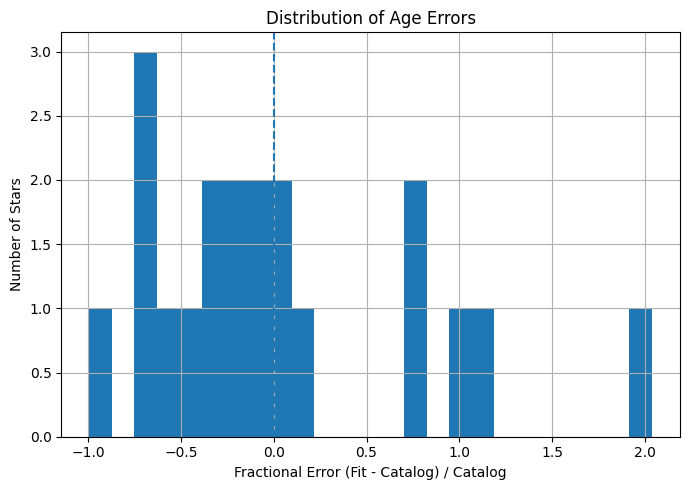

In [50]:
df["frac_error"] = (df["age_median"] - df["age_catalog"]) / df["age_catalog"]

plt.figure(figsize=(7,5))
plt.hist(df["frac_error"], bins=25)

plt.axvline(0, linestyle='--')

plt.xlabel("Fractional Error (Fit - Catalog) / Catalog")
plt.ylabel("Number of Stars")
plt.title("Distribution of Age Errors")

plt.grid(True)
plt.tight_layout()
plt.show()

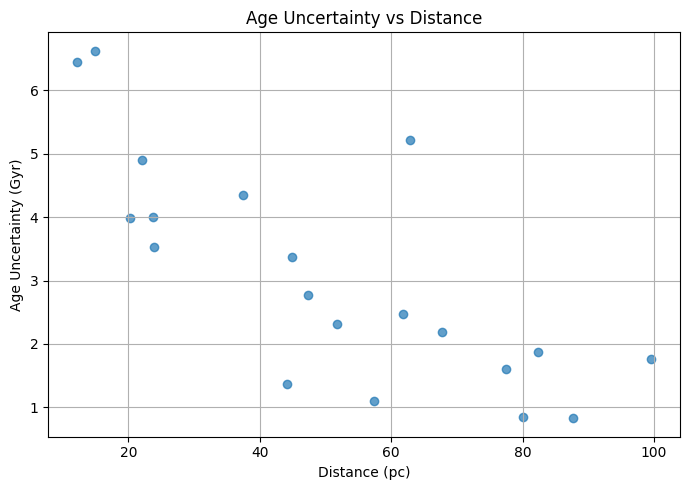

In [51]:
merged_results = pd.merge(results_df, merged_sample[["hostname","distance_pc"]], on="hostname")

plt.figure(figsize=(7,5))

plt.scatter(
    merged_results["distance_pc"],
    merged_results["age_err"],
    alpha=0.7
)

plt.xlabel("Distance (pc)")
plt.ylabel("Age Uncertainty (Gyr)")
plt.title("Age Uncertainty vs Distance")

plt.grid(True)
plt.tight_layout()
plt.show()

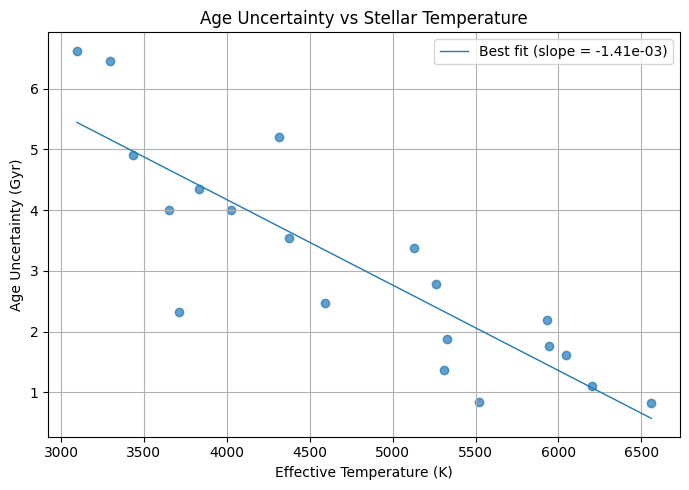

In [53]:
merged_results = pd.merge(results_df, merged_sample[["hostname","st_teff"]], on="hostname")

plt.figure(figsize=(7,5))

plt.scatter(
    merged_results["st_teff"],
    merged_results["age_err"],
    alpha=0.7
)

# line of best fit
x = merged_results["st_teff"].values
y = merged_results["age_err"].values

m, b = np.polyfit(x, y, 1)

x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = m * x_fit + b

plt.plot(x_fit, y_fit, linewidth=1, label=f"Best fit (slope = {m:.2e})")

plt.xlabel("Effective Temperature (K)")
plt.ylabel("Age Uncertainty (Gyr)")
plt.title("Age Uncertainty vs Stellar Temperature")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

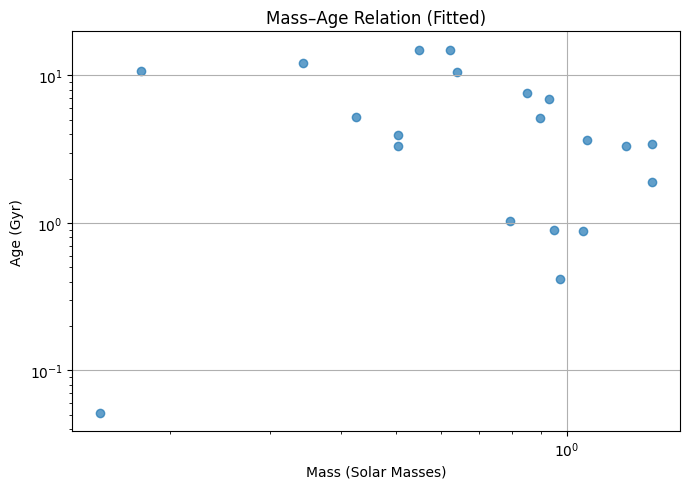

In [54]:
plt.figure(figsize=(7,5))

plt.scatter(
    results_df["mass_median"],
    results_df["age_median"],
    alpha=0.7
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Mass (Solar Masses)")
plt.ylabel("Age (Gyr)")
plt.title("Mass–Age Relation (Fitted)")

plt.grid(True)
plt.tight_layout()
plt.show()

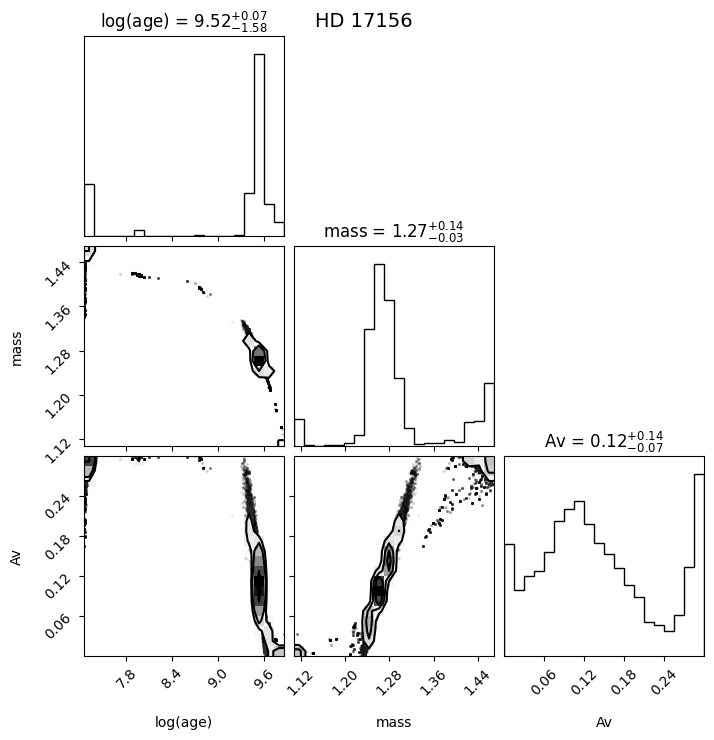

In [63]:
import corner
import matplotlib.pyplot as plt

i = 18  # index of the star you want

samples = sample_list[i]
star_name = results[i]["hostname"]  # or star_dicts[i]["hostname"]

fig = corner.corner(
    samples,
    labels=["log(age)", "mass", "Av"],
    show_titles=True
)

fig.suptitle(f"{star_name}", fontsize=14)

plt.show()

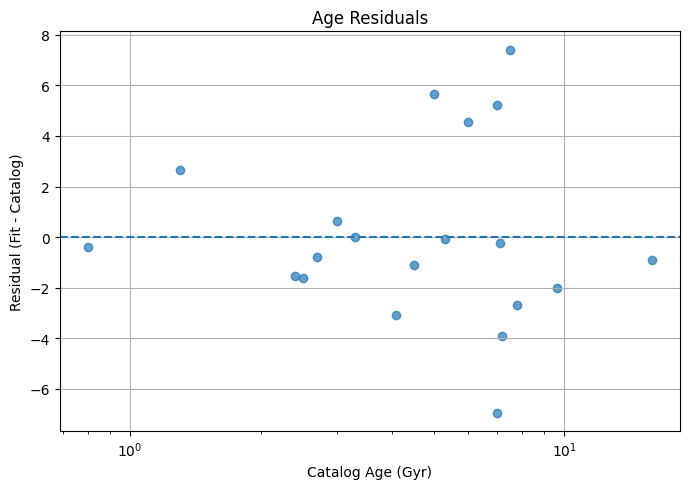

In [56]:
residuals = df["age_median"] - df["age_catalog"]

plt.figure(figsize=(7,5))

plt.scatter(df["age_catalog"], residuals, alpha=0.7)

plt.axhline(0, linestyle='--')

plt.xscale("log")

plt.xlabel("Catalog Age (Gyr)")
plt.ylabel("Residual (Fit - Catalog)")
plt.title("Age Residuals")

plt.grid(True)
plt.tight_layout()
plt.show()

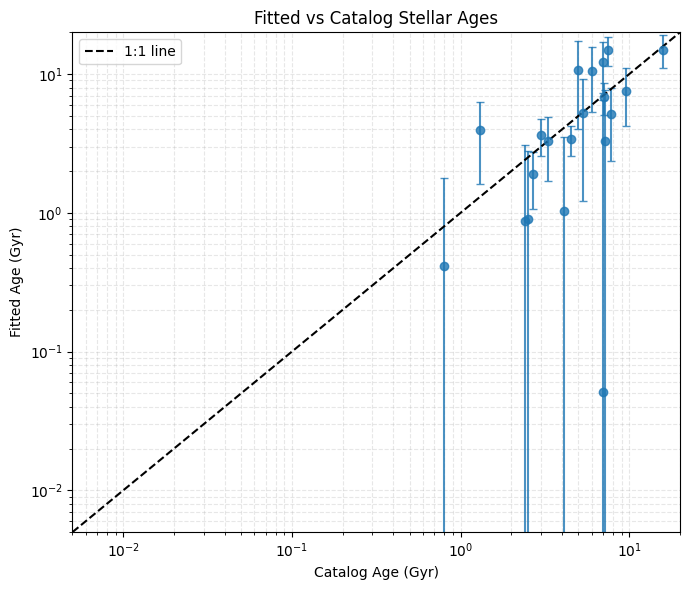

In [44]:
import matplotlib.pyplot as plt
import numpy as np

df = results_df.copy()

plt.figure(figsize=(7,6))

plt.errorbar(
    df["age_catalog"],
    df["age_median"],
    yerr=df["age_err"],
    fmt='o',
    capsize=3,
    alpha=0.8
)

# 1:1 line
lims = [0.005, 20]
plt.plot(lims, lims, 'k--', linewidth=1.5, label="1:1 line")

plt.xscale("log")
plt.yscale("log")

plt.xlim(lims)
plt.ylim(lims)

plt.xlabel("Catalog Age (Gyr)")
plt.ylabel("Fitted Age (Gyr)")
plt.title("Fitted vs Catalog Stellar Ages")

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

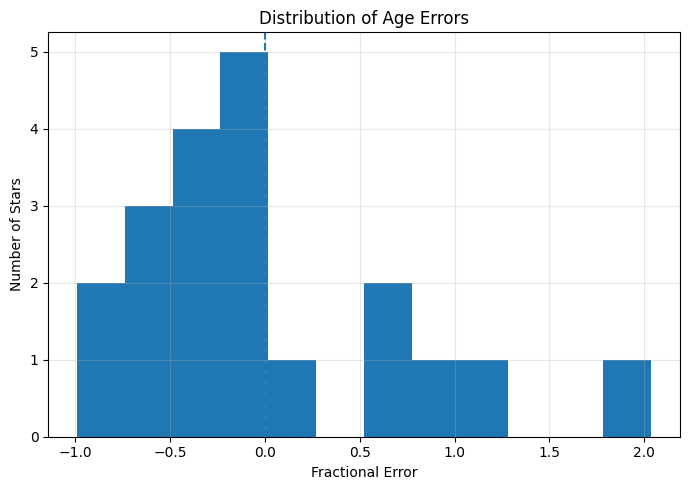

In [29]:
df["frac_error"] = (df["age_median"] - df["age_catalog"]) / df["age_catalog"]

plt.figure(figsize=(7,5))

plt.hist(df["frac_error"], bins=12)

plt.axvline(0, linestyle="--")

plt.xlabel("Fractional Error")
plt.ylabel("Number of Stars")
plt.title("Distribution of Age Errors")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

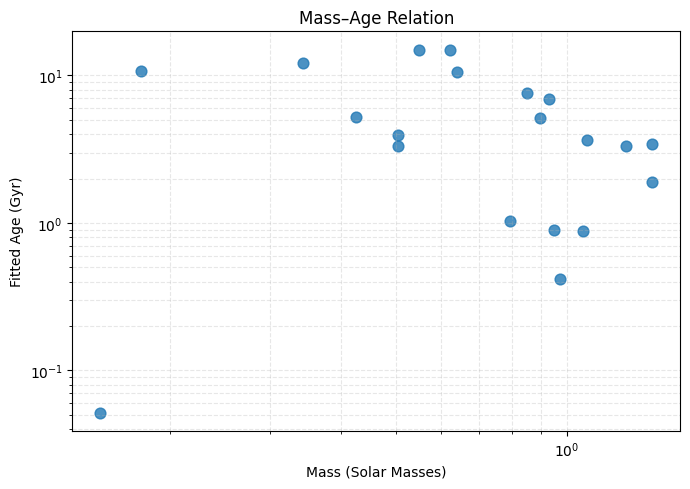

In [30]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["mass_median"],
    df["age_median"],
    s=60,
    alpha=0.8
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Mass (Solar Masses)")
plt.ylabel("Fitted Age (Gyr)")
plt.title("Mass–Age Relation")

plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

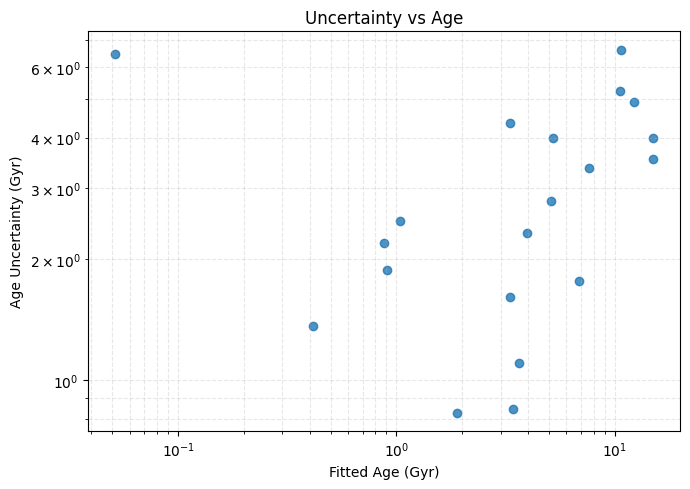

In [31]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["age_median"],
    df["age_err"],
    alpha=0.8
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Fitted Age (Gyr)")
plt.ylabel("Age Uncertainty (Gyr)")
plt.title("Uncertainty vs Age")

plt.grid(True, which="both", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

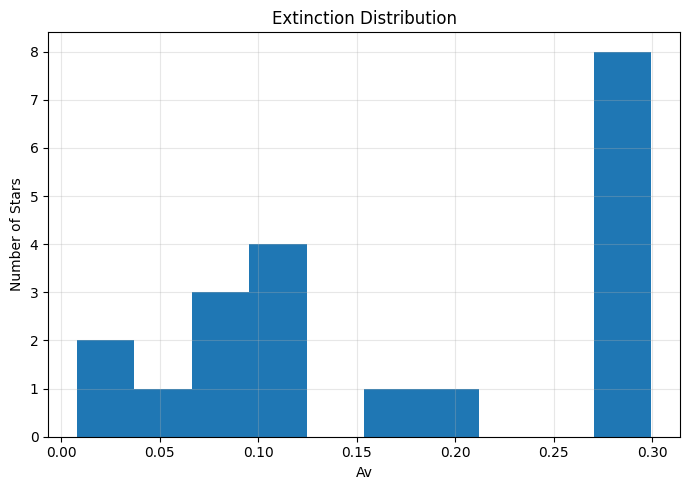

In [32]:
plt.figure(figsize=(7,5))

plt.hist(df["Av_median"], bins=10)

plt.xlabel("Av")
plt.ylabel("Number of Stars")
plt.title("Extinction Distribution")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()